In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import torchvision.utils as vutils
from torchvision import datasets, transforms
import torch
import torch.nn as nn
DEVICE = torch.device("mps")
import wandb
from sklearn.manifold import TSNE
import seaborn as sns
import torch.nn.functional as F


/Users/amirmhd/anaconda3/envs/DL/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/amirmhd/anaconda3/envs/DL/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <5AA8DD3D-A2CC-31CA-8060-88B4E9C18B09> /Users/amirmhd/anaconda3/envs/DL/lib/python3.10/site-packages/torchvision/image.so
  Expected in:     <3E74E253-B679-3D99-83AD-457697D811DA> /Users/amirmhd/anaconda3/envs/DL/lib/python3.10/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


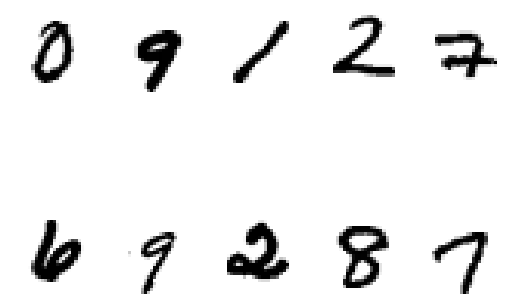

In [2]:
transform = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.1307,), (0.3081,))])

trainset = datasets.MNIST('MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)


testset = datasets.MNIST('MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1024, shuffle=True)



dataiter = iter(trainloader)
images, labels = next(dataiter)

figure = plt.figure()
num_of_images = 10
for index in range(1, num_of_images + 1):
    plt.subplot(2, 5, index)
    plt.axis('off')
    plt.imshow(images[index].numpy().squeeze(), cmap='gray_r')

In [3]:
class Encoder(nn.Module):
    def __init__(self, code_dim):
        super().__init__()
        # input dim = 1 28 28
        self.cnn_1 = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=4, padding=1)  # 4 28 28
        self.max_pool_1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 4 14 14
        self.cnn_2 = nn.Conv2d(in_channels=4, out_channels=16, kernel_size=4, padding=1)  # 16 14 14
        self.max_pool_2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 16 7 7
        self.cnn_3 = nn.Conv2d(in_channels=16, out_channels=64, kernel_size=3, padding=1)  # 64 7 7
        self.max_pool_3 = nn.MaxPool2d(kernel_size=2, stride=2)  # 64 3 3
        self.flatten = nn.Flatten()  # 64 * 3 * 3 = 576
        self.linear_1 = nn.Linear(576, 128)  
        self.non_linear = nn.LeakyReLU()
        self.linear_mean = nn.Linear(128, code_dim) 
        self.linear_logvar = nn.Linear(128, code_dim) 
        
        # self.dropout=nn.Dropout(0.005)
        
    def forward(self, x):
        # x shape: [batch_size, 1, 28, 28]
        x = self.cnn_1(x)

        # x = self.dropout(x)
        x = self.non_linear(x)
        x = self.max_pool_1(x)

        x = self.cnn_2(x)
        # x = self.dropout(x)

        x = self.non_linear(x)
        x = self.max_pool_2(x)

        x = self.cnn_3(x)
        # x = self.dropout(x)

        x = self.non_linear(x)
        x = self.max_pool_3(x)

        x = self.flatten(x)
        x = self.linear_1(x)
        # x = self.dropout(x)
        x = self.non_linear(x)
        mean_z = self.linear_mean(x)
        logvar_z = self.linear_logvar(x)
    

        return mean_z, logvar_z




In [4]:
class Decoder(nn.Module):
  def __init__(self, code_dim):
    super().__init__()
    self.linear_1 = nn.Linear(code_dim, 7 * 7 * 64)
    self.bn0 = nn.BatchNorm1d(7 * 7 * 64)
    self.non_linear = nn.LeakyReLU(0.2)
  # here I will have B 64 7 7  # 64 is channel dim, we start with high channel dim and gradually decrease it
    self.t_conv1 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, padding=1, stride=2)
  # here I will have B 32 14 14
    self.bn1 = nn.BatchNorm2d(32)
    self.t_conv2 = nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, padding=1, stride=1)
    self.bn2 = nn.BatchNorm2d(16)
    self.t_conv3 = nn.ConvTranspose2d(in_channels=16, out_channels=1, kernel_size=4, stride=2, padding=1)
  def forward(self, z):
    out = self.linear_1(z) #expanding to 64*7*7
    out = self.bn0(out)
    out = self.non_linear(out)
    out = out.reshape(out.shape[0], 64, 7, 7)
    out = self.t_conv1(out)
    out = self.bn1(out)
    out = self.non_linear(out)
    out = self.t_conv2(out)
    out = self.bn2(out)
    out = self.non_linear(out)
    out = self.t_conv3(out)
    out = torch.sigmoid(out)
    return out

In [5]:
class VAE(nn.Module):
    def __init__(self, code_dim):
        super().__init__()
        self.encoder = Encoder(code_dim)
        self.decoder = Decoder(code_dim)
        self.code_dim = code_dim
    def sampling(self, mean_, var_):
        epsilon = torch.randn_like(var_).to(DEVICE)
        z = mean_ + var_*epsilon
        return z
                    
    def forward(self, x):
        mean, log_var = self.encoder(x)
        z = self.sampling(mean, torch.exp(log_var/2))
        x_hat = self.decoder(z)
        
        return x_hat, mean, log_var
    
    
        
        

epoch_num: 0
var_loss_test 0.6387876868247986
var_loss_train 0.7293885423938857
KL 0.08850568567086428


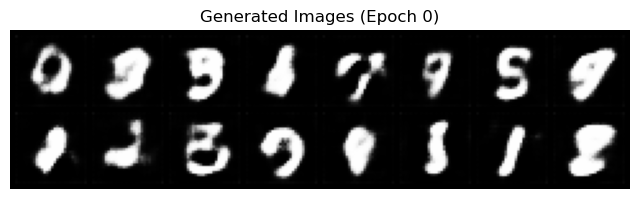

epoch_num: 1
var_loss_test 0.6072043776512146
var_loss_train 0.613984236457963
KL 0.13293153567037094
epoch_num: 2
var_loss_test 0.590255618095398
var_loss_train 0.5926184811825945
KL 0.14328501079636596
epoch_num: 3
var_loss_test 0.5815141797065735
var_loss_train 0.5826687333680419
KL 0.1492115462830326
epoch_num: 4
var_loss_test 0.5800787210464478
var_loss_train 0.5770138910076003
KL 0.15273979560398598
epoch_num: 5
var_loss_test 0.5795553922653198
var_loss_train 0.5733210066996658
KL 0.15477589405040498
epoch_num: 6
var_loss_test 0.5745974183082581
var_loss_train 0.5705598618175938
KL 0.15660902679856145
epoch_num: 7
var_loss_test 0.5740134716033936
var_loss_train 0.568686605008172
KL 0.15764902385948562
epoch_num: 8
var_loss_test 0.5692400932312012
var_loss_train 0.5668961914109268
KL 0.15848413440210224
epoch_num: 9
var_loss_test 0.571160078048706
var_loss_train 0.56545679630247
KL 0.15918760745128843
epoch_num: 10
var_loss_test 0.5692306160926819
var_loss_train 0.5643136953748366

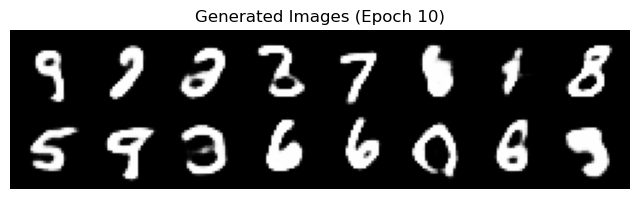

epoch_num: 11
var_loss_test 0.5722872018814087
var_loss_train 0.5636773918991658
KL 0.16033402234633595
epoch_num: 12
var_loss_test 0.5716583132743835
var_loss_train 0.5625341050406255
KL 0.1608518505973348
epoch_num: 13
var_loss_test 0.5710833072662354
var_loss_train 0.5620539182030571
KL 0.16093762568446365
epoch_num: 14
var_loss_test 0.5682754516601562
var_loss_train 0.561314750709005
KL 0.16120739710102203
epoch_num: 15
var_loss_test 0.5664506554603577
var_loss_train 0.5605637438770043
KL 0.16162528586921407
epoch_num: 16
var_loss_test 0.5678820013999939
var_loss_train 0.5597482656619188
KL 0.16205052465899414
epoch_num: 17
var_loss_test 0.5653996467590332
var_loss_train 0.5597300125337613
KL 0.16199989229250056
epoch_num: 18
var_loss_test 0.5641583204269409
var_loss_train 0.55894999984485
KL 0.16209175992113695
epoch_num: 19
var_loss_test 0.5638877749443054
var_loss_train 0.5586014604771824
KL 0.1628024220339525
epoch_num: 20
var_loss_test 0.5630390048027039
var_loss_train 0.55861

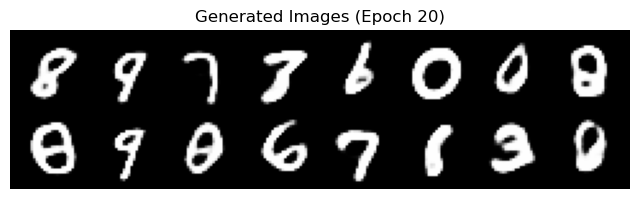

epoch_num: 21
var_loss_test 0.5670850276947021
var_loss_train 0.5578862368933427
KL 0.1626989341049052
epoch_num: 22
var_loss_test 0.563542902469635
var_loss_train 0.5576036736400906
KL 0.1625443648364244
epoch_num: 23
var_loss_test 0.5621049404144287
var_loss_train 0.5573402589826442
KL 0.16270897488222955
epoch_num: 24
var_loss_test 0.5667794346809387
var_loss_train 0.5570944941628462
KL 0.16273072597060376
epoch_num: 25
var_loss_test 0.5637476444244385
var_loss_train 0.5564880868010937
KL 0.16312415605541994
epoch_num: 26
var_loss_test 0.5598729252815247
var_loss_train 0.5563874434052246
KL 0.16299487288191375
epoch_num: 27
var_loss_test 0.5601109862327576
var_loss_train 0.5561868723775787
KL 0.16334584186961656
epoch_num: 28
var_loss_test 0.5618518590927124
var_loss_train 0.5561940190888671
KL 0.16322568732538204
epoch_num: 29
var_loss_test 0.5620869398117065
var_loss_train 0.5557695238320812
KL 0.1636199409455887
epoch_num: 30
var_loss_test 0.5619891881942749
var_loss_train 0.5556

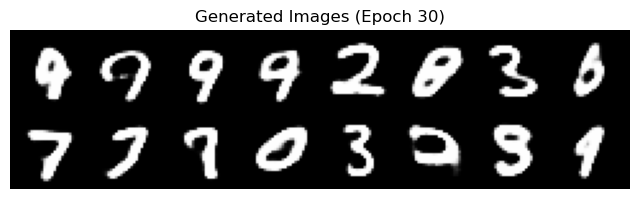

epoch_num: 31
var_loss_test 0.561421275138855
var_loss_train 0.5553311077770648
KL 0.16327846790554681
epoch_num: 32
var_loss_test 0.5610448122024536
var_loss_train 0.555506459685531
KL 0.16365955223533898


In [6]:
epochs = 33
embedding_dim = 64
vae = VAE(embedding_dim).to(DEVICE)
optim = torch.optim.Adam(lr=0.001, params=vae.parameters() )
img_list = []

loss_mse = torch.nn.MSELoss().to(DEVICE)
# P_theta(X|Z) + KL Q(Z|X) || P(Z)
x_test,_ = next(iter(testloader))
x_test=x_test.to(DEVICE)

# wandb.init(project="vae", name="vae")


for epoch in range(epochs):
    fixed_noise = torch.randn(64, embedding_dim).to(DEVICE)
    running_loss_kl=0
    running_loss_mse=0
    running_loss_total=0
    for i, (x_batch, _) in enumerate(trainloader):
        x_batch=x_batch.to(DEVICE)
        x_hat, mean_z, logvar_z = vae(x_batch)
        var_loss_KL = -0.5 * torch.mean( 1+ logvar_z - mean_z.pow(2) -logvar_z.exp() )
        var_loss_mse = loss_mse(x_hat, x_batch)
        loss_total = 0.3*var_loss_KL + 0.7*var_loss_mse
        optim.zero_grad()
        loss_total.backward()
        optim.step()
        running_loss_kl += var_loss_KL.item()
        running_loss_mse += var_loss_mse.item()
        running_loss_total += loss_total.item()
    ############
    with torch.no_grad():
        test_x_hat, _, _ = vae(x_test)
        test_loss = loss_mse(test_x_hat, x_test).item()
    
    # Average loss for the epoch
    avg_loss_kl = running_loss_kl / len(trainloader)
    avg_loss_mse = running_loss_mse / len(trainloader)
    avg_loss_total = running_loss_total / len(trainloader)
    
    # wandb.log({
    #     "epoch": epoch,
    #     "train_loss_total": avg_loss_total,
    #     "train_loss_mse": avg_loss_mse,
    #     "train_loss_kl": avg_loss_kl,
    #     "test_loss_mse": test_loss
    # })
    
    print(f"epoch_num: {epoch}")
    print(f"var_loss_test {test_loss}")
    print(f"var_loss_train {avg_loss_mse}")
    print(f"KL {avg_loss_kl}")
    if epoch%10==0:
        fake = vae.decoder(fixed_noise).detach().cpu()
        img_list.append(vutils.make_grid(fake[:16], padding=2, normalize=True))    
        plt.figure(figsize=(8, 8))
        plt.axis("off")
        plt.title(f"Generated Images (Epoch {epoch})")
        plt.imshow(np.transpose(img_list[-1], (1, 2, 0)))
        plt.show()



        

In [7]:
def generator(num_samples, model):
    noise = torch.randn(num_samples, model.code_dim).to(DEVICE)
    gen_images = model.decoder(noise).detach().cpu()   
    return gen_images

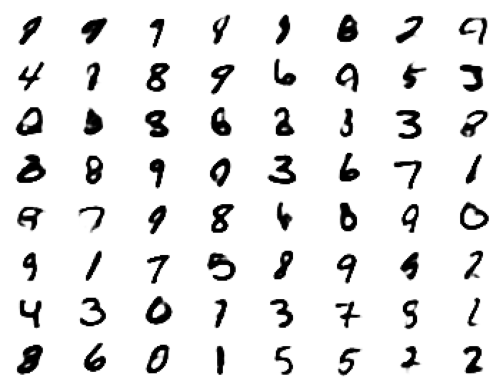

In [8]:
figure = plt.figure()
num_of_images=64
gen=generator(num_of_images, vae)
for index in range(0, num_of_images):
    plt.subplot(8, 8, index+1)
    plt.axis('off')
    plt.imshow(gen[index].numpy().squeeze(), cmap='gray_r')

## Metrics

### Encoder's Performance

if the data is linearly seperable then the encoder is a good encoder! We encod the data then apply tsne to see how seperable is the encoder

In [9]:
x_test,y_test = next(iter(testloader))
x_test=x_test.to(DEVICE)
mu, log_sigma = vae.encoder(x_test)
mu_np = mu.detach().cpu().numpy()
y_test_np = y_test.cpu().numpy()

tsne = TSNE(n_components=2, random_state=42)
mu_tsne = tsne.fit_transform(mu_np)

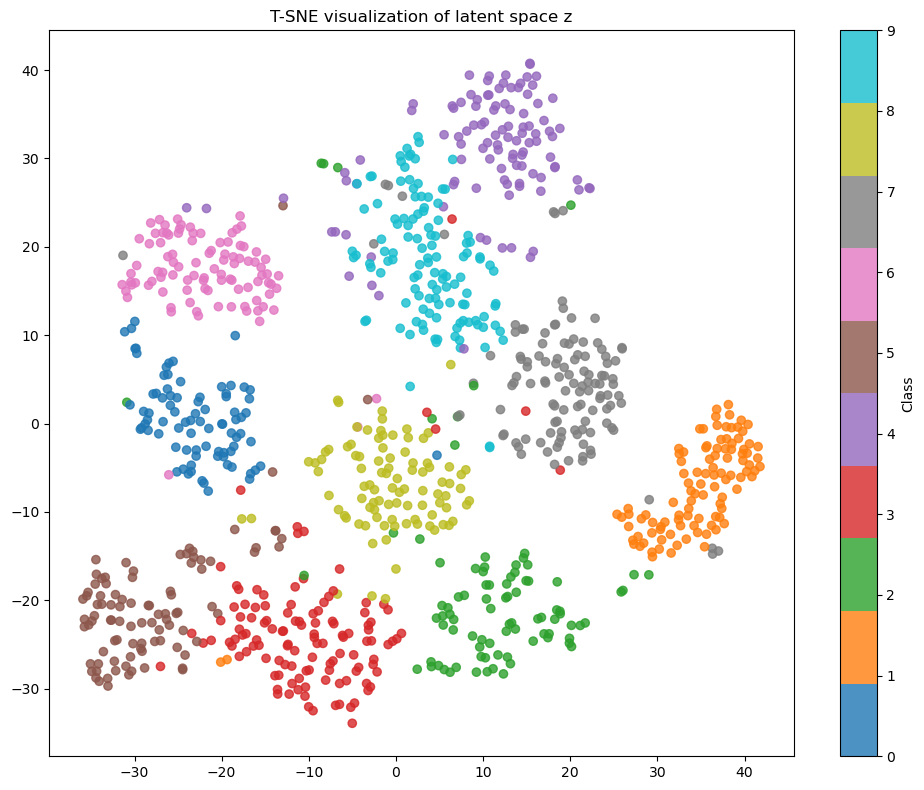

In [10]:


plt.figure(figsize=(10, 8))
scatter = plt.scatter(mu_tsne[:, 0], mu_tsne[:, 1], c=y_test_np,cmap='tab10', alpha=0.8)
plt.colorbar(scatter, label='Class')
plt.title('T-SNE visualization of latent space z')
plt.tight_layout()
plt.show()

## Generation Performance

### Here is an example how it generates

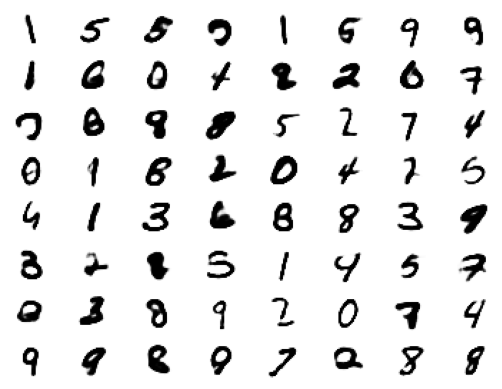

In [11]:
figure = plt.figure()
num_of_images=64
gen=generator(num_of_images, vae)
for index in range(0, num_of_images):
    plt.subplot(8, 8, index+1)
    plt.axis('off')
    plt.imshow(gen[index].numpy().squeeze(), cmap='gray_r')

### Training LeNet on MNIST to see how features are really!

#### LeNet Model

In [12]:

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(400, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)   

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 400)
        x = F.relu(self.fc1(x))
        features = F.relu(self.fc2(x))  #m by 84
        x = self.fc3(features)
        return x, features

#### Training LeNet

In [13]:
model = LeNet()
model.to(DEVICE)
epochs=20
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.001,momentum=0.9)


for epoch in range(epochs):
    for i, data in enumerate(trainloader):
        inputs,labels=data
        inputs,labels= inputs.to(DEVICE) , labels.to(DEVICE)
        optimizer.zero_grad()
        outputs, _ =model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer .step()
    print(f'Epoch {epoch+1} completed')




Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed


In [14]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs, _=model(images)
        _, predicted=torch.max(outputs.data, 1)
        total+=labels.size(0)
        correct+=(predicted == labels).sum().item()

accuracy=100*correct/total
print(accuracy)


98.36


### Computing FID

In [15]:

features = []

with torch.no_grad():
    for data in testloader:
        images, _= data  
        images =images.to(DEVICE)
        _, batch_features = model(images)
        features.append(batch_features.cpu().numpy())

features_groundTruth = np.concatenate(features, axis=0)




In [16]:
print(images.shape)
gen.shape

torch.Size([784, 1, 28, 28])


torch.Size([64, 1, 28, 28])

In [17]:
num_of_images=features_groundTruth.shape[0]
gen=generator(num_of_images, vae)

_, features_VAE = model(gen.to(DEVICE))
features_VAE = features_VAE.detach().cpu().numpy()

In [18]:
def calculate_fid(real_features, gen_features):
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = gen_features.mean(axis=0), np.cov(gen_features, rowvar=False)
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    fid = ssdiff
    return fid

In [19]:
calculate_fid(features_VAE,features_groundTruth)

377.0968

### Visualy Confirming :|

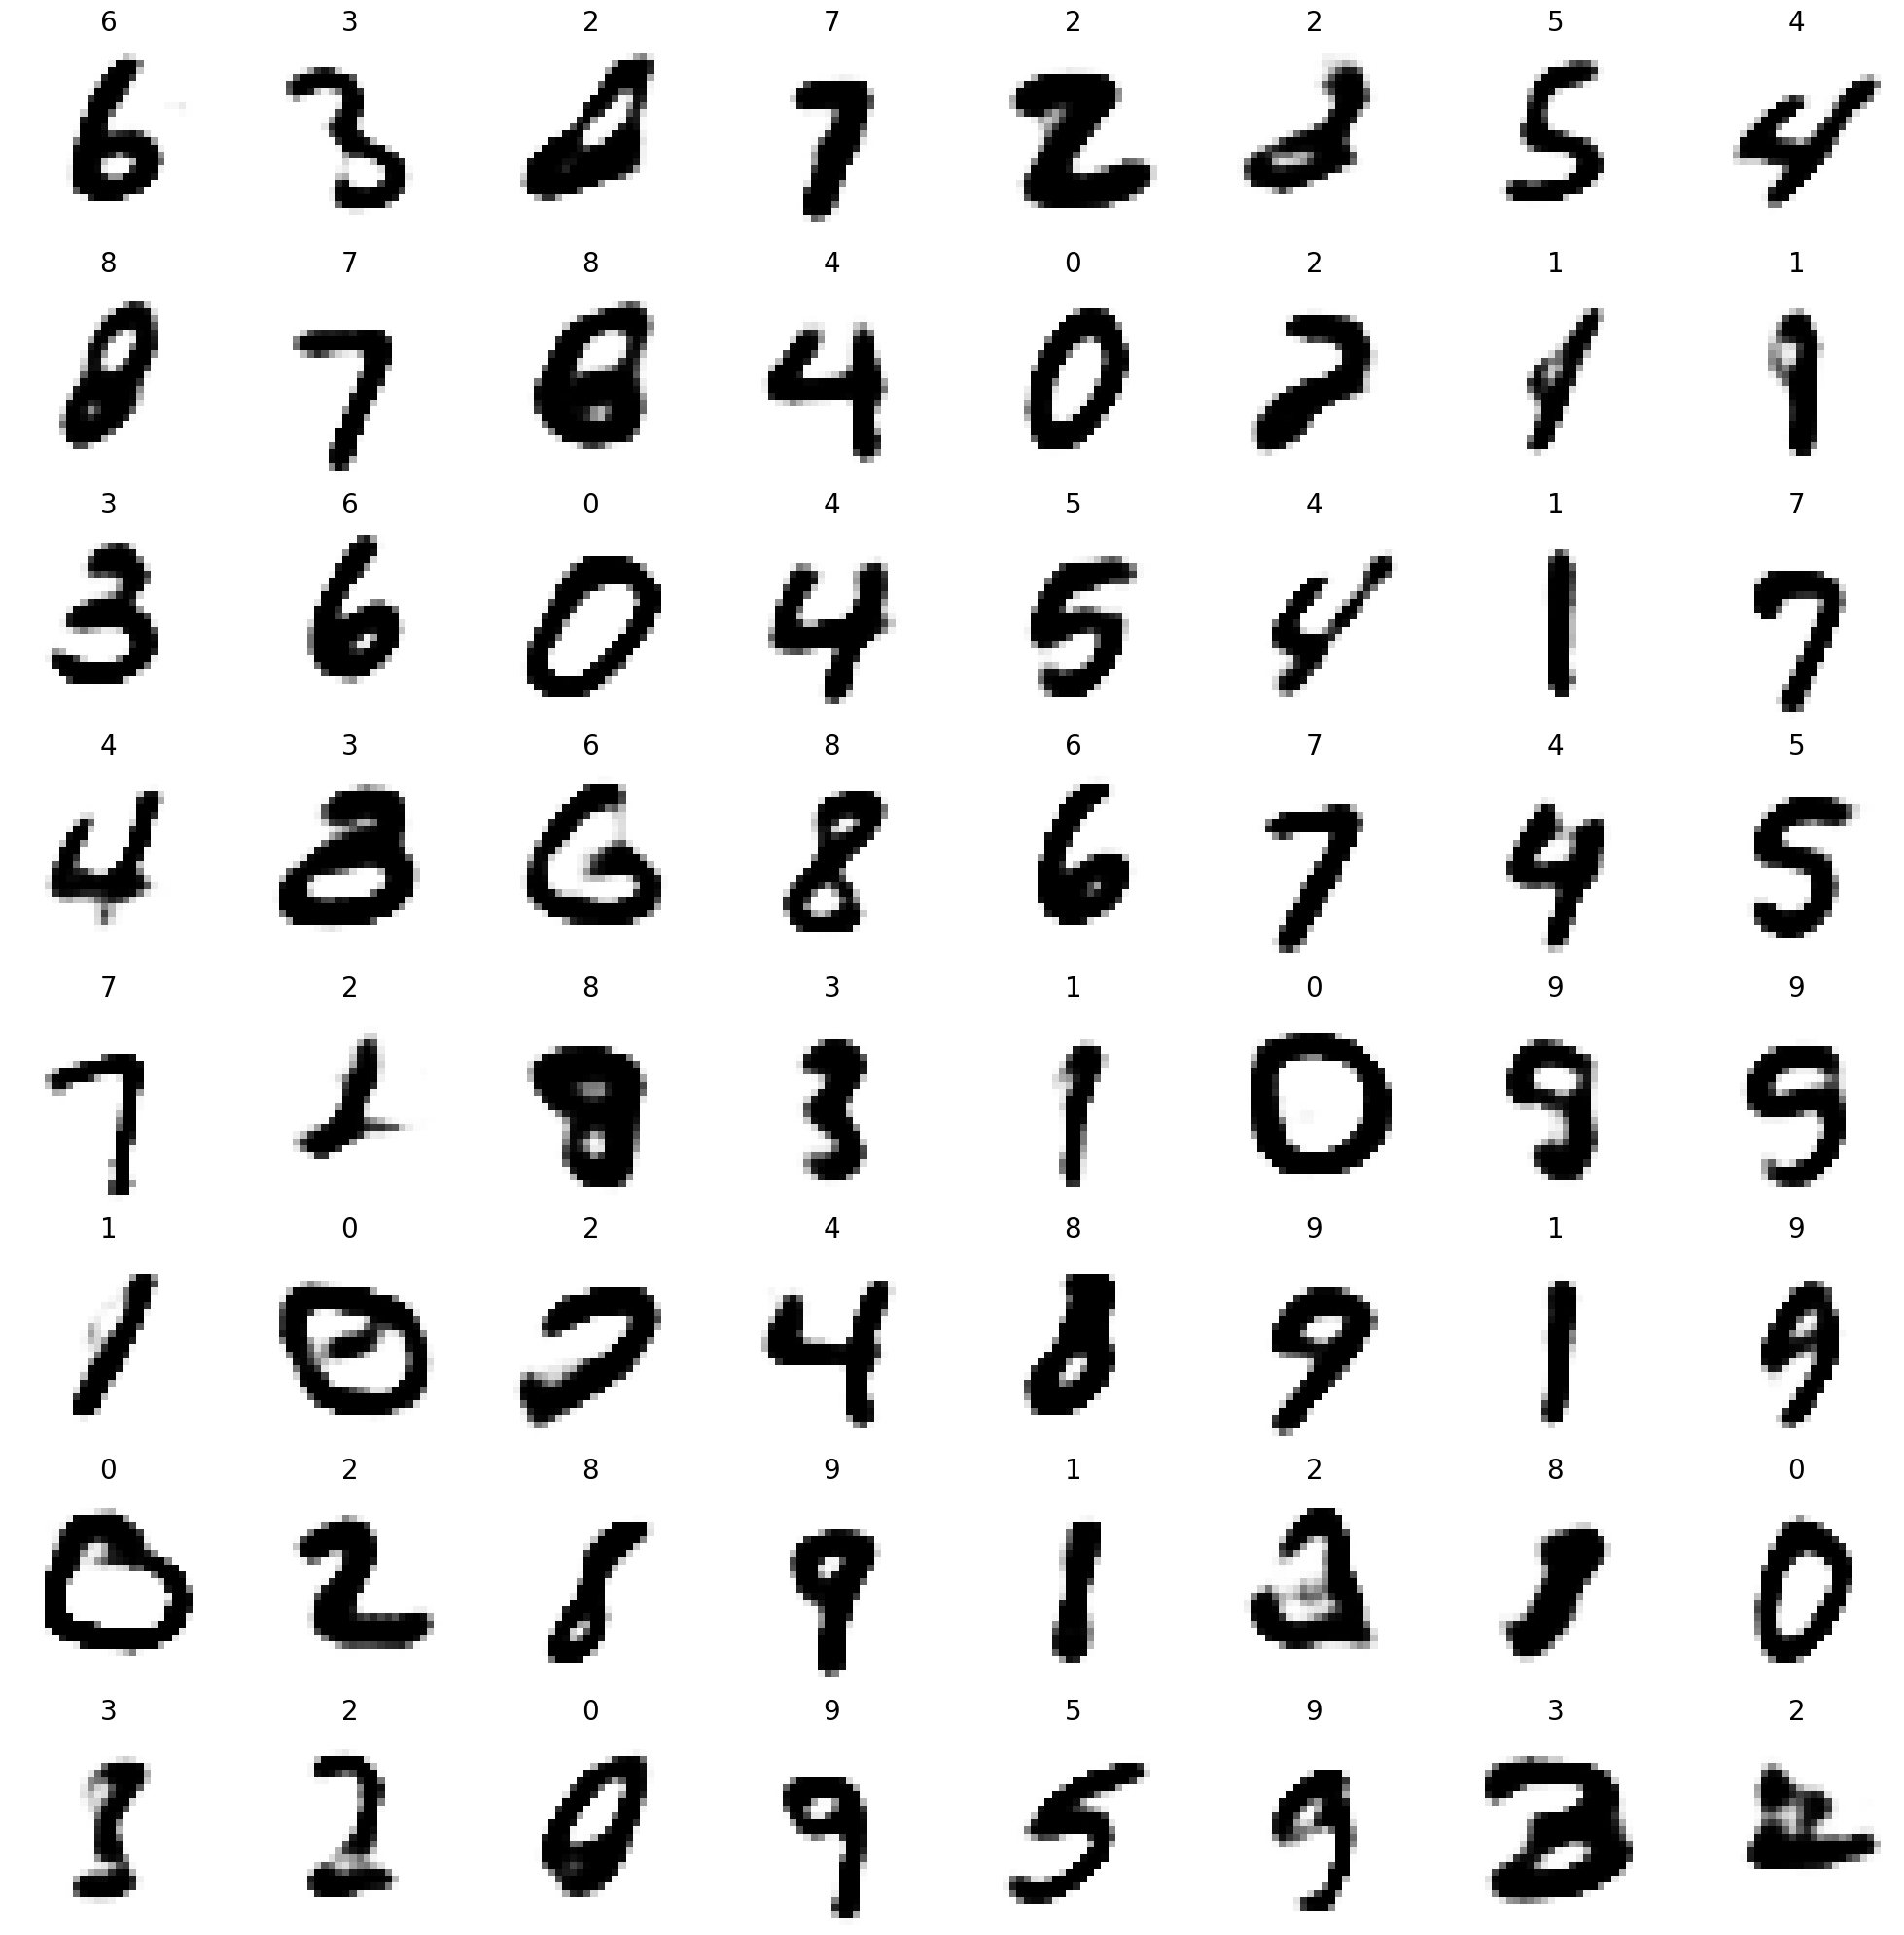

In [20]:
figure = plt.figure(figsize=(20, 20))  # Increase the figure size
num_of_images=64
gen=generator(num_of_images, vae)
prediction_, features = model(gen.to(DEVICE))
# print(prediction_.shape)
pred_class = torch.argmax(prediction_, dim=1)

for index in range(0, num_of_images):

    
    plt.subplot(8, 8, index+1)
    plt.axis('off')
    plt.title(f'{pred_class[index]}', fontsize=20)

    plt.imshow(gen[index].numpy().squeeze(), cmap='gray_r')
plt.tight_layout()


In [21]:
num_of_images=256
gen=generator(num_of_images, vae)
prediction_, features = model(gen.to(DEVICE))
pred_class = torch.argmax(prediction_, dim=1)

Text(0.5, 1.0, 'Distribution of Predicted Classes')

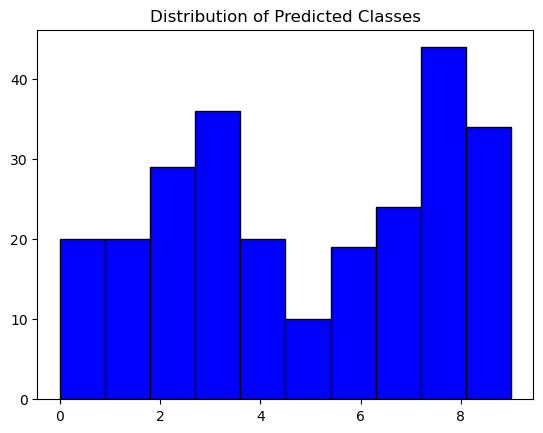

In [22]:
plt.hist(pred_class.cpu().numpy(), bins=10, edgecolor='black', color='blue')


plt.title('Distribution of Predicted Classes')

### IS Score

In [24]:
num_images=1000
batch_size=100
splits=10

vae.eval()
model.eval()
generated_images = generator(num_images, vae)
generated_images = generated_images.to(DEVICE)
preds = []

with torch.no_grad():
    preds, _  = model(generated_images)
    preds = F.softmax(preds, dim=1)
    preds = preds.cpu().numpy()
print(preds.shape)

(1000, 10)


In [25]:

p_y = np.mean(preds, axis=0)
    
kl_divergences = []
for j in range(preds.shape[0]):
    p_y_given_x = preds[j]
    kl_divergence = np.sum(p_y_given_x * np.log(p_y_given_x/(p_y)))
    kl_divergences.append(kl_divergence)
is_score = np.exp(np.mean(kl_divergences))

is_score

3.9611182

Text(0.5, 1.0, 'Marginal Distribution')

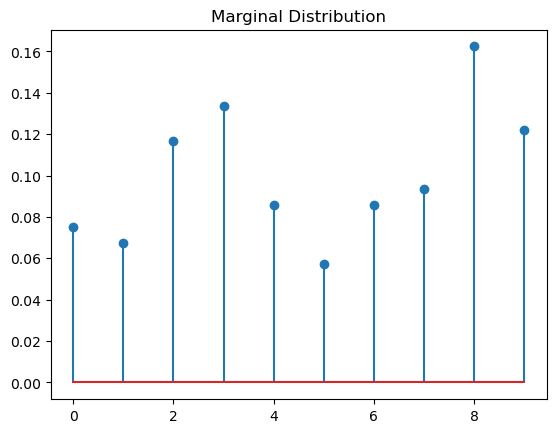

In [26]:
plt.stem(p_y)
plt.title("Marginal Distribution")